Step 1: Install Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Dtep 2: Load Dataset

In [8]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Step 3: Basic Data Checks

In [9]:
df.shape

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Step 4: Data Cleaning

In [10]:
df['Order Date']=pd.to_datetime(df['Order Date'])

df['Ship Date']=pd.to_datetime(df['Ship Date'])

df.drop_duplicates(inplace=True)

df['Year']=df['Order Date'].dt.year

df['Month']=df['Order Date'].dt.month

df['Profit Margin']=df['Profit']/df['Sales']

Step 5: Business Analysis

Total Sales:

In [11]:
df['Sales'].sum()

np.float64(2297200.8603000003)

Total Profit:

In [12]:
df['Profit'].sum()

np.float64(286397.0217)

Sales by Category:

In [13]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


Profit by Category:

In [14]:
df.groupby('Category')['Profit'].sum()

,Profit
Category,
Furniture,18451.2728
Office Supplies,122490.8008
Technology,145454.9481


Region Performance:

In [15]:
df.groupby('Region')['Profit'].sum()

,Profit
Region,
Central,39706.3625
East,91522.7800
South,46749.4303
West,108418.4489


Loss making products:

In [16]:
df[df['Profit']<0].sort_values(by='Profit')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Profit Margin
7772,7773,CA-2016-108196,2016-11-25,2016-12-02,Standard Class,CS-12505,Cindy Stewart,Consumer,United States,Lancaster,...,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780,2016,11,-1.466667
683,684,US-2017-168116,2017-11-04,2017-11-04,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,...,Technology,Machines,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904,2017,11,-0.480000
9774,9775,CA-2014-169019,2014-07-26,2014-07-30,Standard Class,LF-17185,Luke Foster,Consumer,United States,San Antonio,...,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928,2014,7,-1.700000
3011,3012,CA-2017-134845,2017-04-17,2017-04-23,Standard Class,SR-20425,Sharelle Roach,Home Office,United States,Louisville,...,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,2549.985,5,0.7,-3399.9800,2017,4,-1.333333
4991,4992,US-2017-122714,2017-12-07,2017-12-13,Standard Class,HG-14965,Henry Goldwyn,Corporate,United States,Chicago,...,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,1889.990,5,0.8,-2929.4845,2017,12,-1.550000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4660,4661,CA-2015-112130,2015-05-03,2015-05-07,Standard Class,SV-20785,Stewart Visinsky,Consumer,United States,Philadelphia,...,Technology,Accessories,SanDisk Cruzer 16 GB USB Flash Drive,27.552,3,0.2,-0.3444,2015,5,-0.012500
7413,7414,CA-2017-121125,2017-05-30,2017-06-03,Standard Class,MG-17890,Michael Granlund,Home Office,United States,Tigard,...,Furniture,Furnishings,Tensor Brushed Steel Torchiere Floor Lamp,13.592,1,0.2,-0.3398,2017,5,-0.025000
1566,1567,CA-2015-129112,2015-11-29,2015-11-30,First Class,AW-10840,Anthony Witt,Consumer,United States,Allen,...,Technology,Accessories,Kingston Digital DataTraveler 16GB USB 2.0,21.480,3,0.2,-0.2685,2015,11,-0.012500
1496,1497,CA-2017-152485,2017-09-04,2017-09-08,Standard Class,JD-15790,John Dryer,Consumer,United States,Coppell,...,Office Supplies,Storage,Acco Perma 3000 Stacking Storage Drawers,16.784,1,0.2,-0.2098,2017,9,-0.012500


In [ ]:
Monthly trend:

In [17]:
df.groupby('Month')['Sales'].sum()

,Sales
Month,
1,94924.8356
2,59751.2514
3,205005.4888
4,137762.1286
5,155028.8117
6,152718.6793
7,147238.0970
8,159044.0630
9,307649.9457


Segment analysis:

In [18]:
df.groupby('Segment')['Profit'].sum()

,Profit
Segment,
Consumer,134119.2092
Corporate,91979.1340
Home Office,60298.6785


Step 6: Visualization

Sales by category:

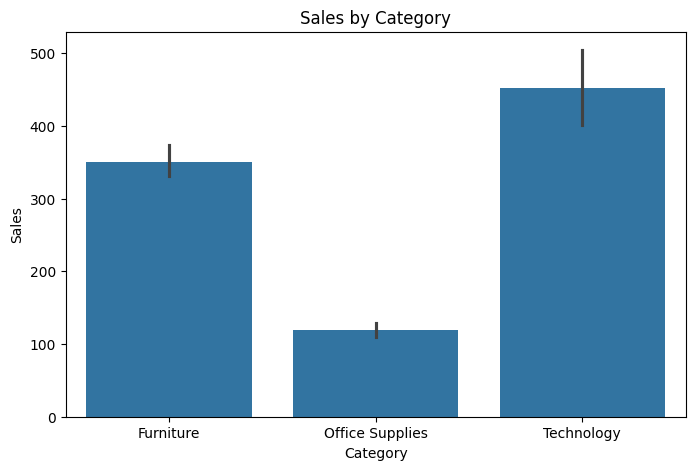

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(x='Category',y='Sales',data=df)

plt.title("Sales by Category")

plt.show()

Profit by region:

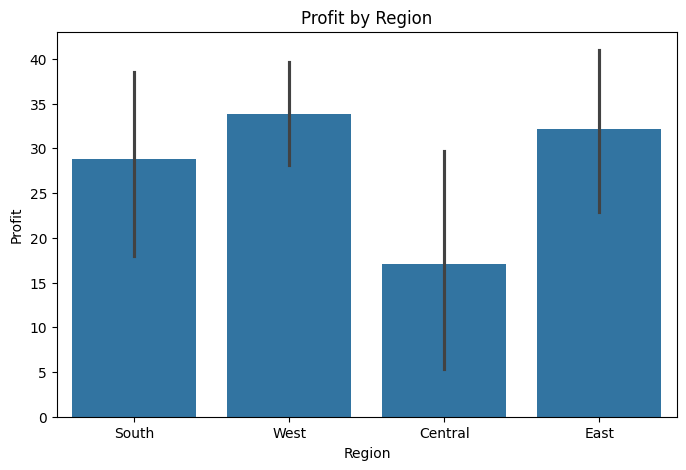

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(x='Region',y='Profit',data=df)

plt.title("Profit by Region")

plt.show()

Monthly trend:

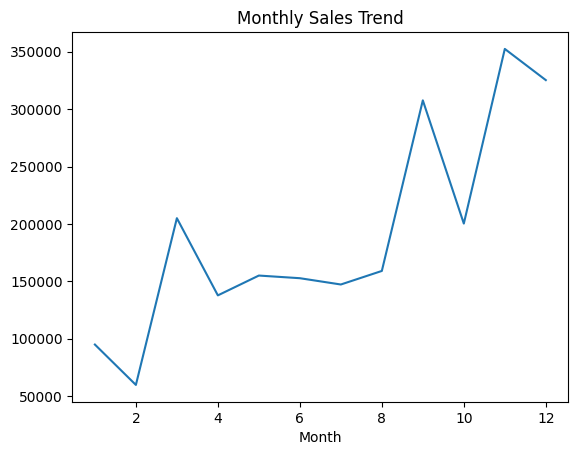

In [21]:
df.groupby('Month')['Sales'].sum().plot()

plt.title("Monthly Sales Trend")

plt.show()

Loss categories:

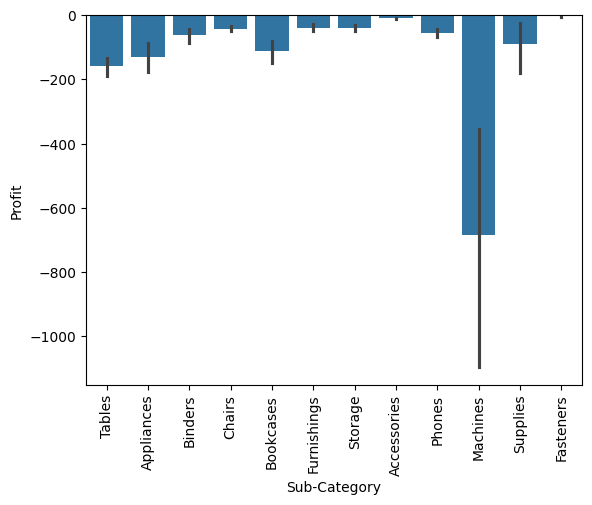

In [22]:
loss=df[df['Profit']<0]

sns.barplot(x='Sub-Category',y='Profit',data=loss)

plt.xticks(rotation=90)

plt.show()

Step 7: Business Insights
Key Findings from Sales Analysis
Sales Performance

• Technology category generated the highest profit among all categories
• Office Supplies category showed stable sales performance
• Furniture category generated losses despite good sales volume

Regional Performance

• West region recorded the highest sales and profit
• Central region showed lower profitability compared to others
• South region had moderate performance

Product Insights

• Some sub-categories like Tables and Bookcases are causing major losses
• Phones and Accessories are among top revenue generating products

Customer Segment Insights

• Consumer segment contributes highest sales
• Corporate segment shows stable profit margins
• Home Office segment has lowest contribution

Time Trends

• Sales peak during November and December (holiday season impact)
• Early months show comparatively lower sales

Business Recommendations

• Reduce discounts on loss-making furniture products
• Focus marketing on Technology category
• Improve strategy in Central region
• Promote high profit products
• Review pricing strategy for loss generating items

Conclusion

The analysis shows that focusing on profitable categories and reducing losses in furniture products can significantly improve overall profitability.